# All-Chile Glacier Runoff Contribution to Streamflow

## Overview
This notebook quantifies glacier melt contributions to streamflow across all of Chile,
comparing results across three OGGM climate forcing datasets.

## Methods summary

### Glacier-to-basin assignment
RGI glacier centroids are spatially joined to all 516 CAMELS-CL gauge catchment polygons
(`camels_cl_boundaries.shp`). Because CAMELS-CL uses a nested catchment hierarchy,
a single glacier may fall within multiple overlapping polygons (e.g. Allipen sub-basin
AND the larger Tolten catchment). This is **intentional**: glacier melt physically
passes through all downstream gauges, so the same glacier contributes to the streamflow
fraction at every gauge in its drainage network.

### Total Chile melt (de-duplicated)
For national-scale totals, each glacier is assigned to its **smallest containing
catchment only** (minimum `area_km2` among all matched polygons). This prevents
double-counting when summing melt across the country.

### Q completeness filter
Only gauges with >= `MIN_COMPLETE_YEARS` complete years (all 12 months non-NaN, Q > 0)
within 2000-2019 are included in the streamflow fraction analysis. Gauges below this
threshold are retained for national melt totals only. Fractions are computed only
for months where Q is non-NaN and > 0 — missing Q months are excluded from all averages.

### Climate forcings
- **CR2MET** (~5 km): `run_output_2000_2019_hydro_TC_{cluster}.nc`
- **ERA5** (~30 km): `run_output_2000_2019_hydro_ERA5_{cluster}.nc`
- **CRU** (~55 km): `run_output_2000_2019_hydro_CRU_{cluster}.nc`

All three are calibrated against Hugonnet et al. (2021) geodetic mass balance.
Melt volumes diverge despite identical 20-year mean SMB (accumulation-melt compensation).

### Glacier runoff definition
Glacier runoff = melt on glacier + liquid precipitation on glacier.
NetCDF values are in **kg** — divide by `WATER_DENSITY` (1000 kg/m3) to get m3.

### Analysis period
2000-2019. NetCDF time axis starts at 1999 (spinup, `YEAR_OFFSET=1`).

In [1]:
# ── Cell 1: Imports & constants ───────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Physical constants
ICE_DENSITY   = 900    # kg/m3
WATER_DENSITY = 1000   # kg/m3
# NOTE: melt_on_glacier_monthly and liq_prcp_on_glacier_monthly in cluster
# NetCDFs are stored in kg. Divide by WATER_DENSITY to convert to m3.

# Analysis window
YEARS       = list(range(2000, 2020))
MONTHS      = list(range(1, 13))
YEAR_OFFSET = 1   # NetCDF time axis: [1999, 2000, ..., 2022]; index 1 = 2000

# Q completeness threshold
MIN_COMPLETE_YEARS = 10  # lower to 8 to include Calle Calle (10122001)

# OGGM cluster regions (north to south)
CLUSTERS = ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']

# Climate datasets: name -> filename tag
DATASETS = {
    'CR2MET': 'TC',
    'ERA5':   'ERA5',
    'CRU':    'CRU',
}

REGION_LABELS = {
    'OT3': 'Altiplano (OT3)',
    'DA1': 'Dry Andes N (DA1)',
    'DA2': 'Dry Andes C (DA2)',
    'DA3': 'Dry Andes S (DA3)',
    'WA1': 'Wet Andes N (WA1)',
    'WA2': 'Wet Andes C (WA2)',
    'WA3': 'N Patagonia (WA3)',
    'WA4': 'S Patagonia (WA4)',
    'WA5': 'Patagonia (WA5)',
    'WA6': 'Tierra del Fuego (WA6)',
}

DS_COLORS = {'CR2MET': '#1f77b4', 'ERA5': '#ff7f0e', 'CRU': '#2ca02c'}

print('Cell 1 complete')

Cell 1 complete


In [2]:
# ── Cell 2: Paths ─────────────────────────────────────────────────────────
OUTPUT_ROOT = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output'
CAMELS_FULL = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Full_CAMELS_all_basins/CAMELS_CL_v202201'
RGI_PATH    = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'
BOUNDS_PATH = f'{CAMELS_FULL}/camels_cl_boundaries/camels_cl_boundaries.shp'

OUT_DIR = f'{OUTPUT_ROOT}/all_chile_results_v2'
os.makedirs(OUT_DIR, exist_ok=True)

def nc_path(dataset_name, cluster):
    tag = DATASETS[dataset_name]
    return f'{OUTPUT_ROOT}/{dataset_name}/{cluster}/run_output_2000_2019_hydro_{tag}_{cluster}.nc'

print('NetCDF availability:')
all_ok = True
for ds_name in DATASETS:
    missing = [cl for cl in CLUSTERS if not os.path.exists(nc_path(ds_name, cl))]
    status = 'all present' if not missing else f'MISSING: {missing}'
    print(f'  {ds_name:8s}: {status}')
    if missing: all_ok = False
print('All 30 NetCDFs found' if all_ok else 'WARNING: some files missing')

NetCDF availability:
  CR2MET  : all present
  ERA5    : all present
  CRU     : all present
All 30 NetCDFs found


In [3]:
# ── Cell 3: Spatial join — assign RGI glaciers to CAMELS gauge polygons ───
#
# METHOD: Point-in-polygon join using glacier centroids.
# Glaciers assigned to ALL containing polygons (nested basins intentional).
# De-duplicated version assigns each glacier to smallest basin only
# — used for national melt totals to avoid double-counting.

rgi_bna = pd.read_csv(RGI_PATH)
rgi_bna['COD_CUEN'] = rgi_bna['COD_CUEN'].astype(str).str.strip()
rgi_gdf = gpd.GeoDataFrame(
    rgi_bna,
    geometry=gpd.points_from_xy(rgi_bna['CenLon'], rgi_bna['CenLat']),
    crs='EPSG:4326'
)
print(f'RGI glaciers: {len(rgi_gdf)}')

bounds = gpd.read_file(BOUNDS_PATH)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)
print(f'CAMELS gauges: {len(bounds)}')

q_wide = pd.read_csv(f'{CAMELS_FULL}/q_m3s_mon.csv', parse_dates=['date'])
q_wide = q_wide[(q_wide['year'] >= 2000) & (q_wide['year'] <= 2019)].reset_index(drop=True)
q_gauges = set(q_wide.columns[4:].astype(str))
print(f'Gauges with Q data: {len(q_gauges)}')

# Spatial join (all nested assignments)
joined = gpd.sjoin(
    rgi_gdf,
    bounds[['gauge_id','gauge_name','area_km2','geometry']],
    how='left', predicate='within'
)
joined_valid = joined[joined['gauge_id'].notna()].copy()
joined_valid = joined_valid[joined_valid['gauge_id'].isin(q_gauges)]

print(f'\nNESTED (all assignments):')
print(f'  Glacier-gauge pairs: {len(joined_valid)}')
print(f'  Unique glaciers:     {joined_valid["RGIId"].nunique()}')
print(f'  Unique gauges:       {joined_valid["gauge_id"].nunique()}')

# De-duplicated (smallest basin per glacier) for national totals
joined_dedup = (joined_valid
                .sort_values('area_km2')
                .groupby('RGIId', as_index=False)
                .first())

print(f'\nDE-DUPLICATED (smallest basin):')
print(f'  Unique glaciers: {len(joined_dedup)}')
print(f'  Unique gauges:   {joined_dedup["gauge_id"].nunique()}')

# Build GAUGE_INFO (nested)
GAUGE_INFO = {}
for gauge_id, grp in joined_valid.groupby('gauge_id'):
    GAUGE_INFO[gauge_id] = {
        'gauge_name':       grp['gauge_name'].iloc[0],
        'rgi_ids':          grp['RGIId'].tolist(),
        'n_glaciers':       len(grp),
        'glacier_area_km2': grp['Area'].sum(),
        'basin_area_km2':   grp['area_km2'].iloc[0],
        'clusters':         sorted(grp['Cluster'].unique().tolist()),
        'cen_lat':          grp['CenLat'].mean(),
        'cen_lon':          grp['CenLon'].mean(),
    }

# Build GAUGE_INFO_DEDUP (de-duplicated)
GAUGE_INFO_DEDUP = {}
for gauge_id, grp in joined_dedup.groupby('gauge_id'):
    GAUGE_INFO_DEDUP[gauge_id] = {
        'gauge_name':       grp['gauge_name'].iloc[0],
        'rgi_ids':          grp['RGIId'].tolist(),
        'n_glaciers':       len(grp),
        'glacier_area_km2': grp['Area'].sum(),
        'basin_area_km2':   grp['area_km2'].iloc[0],
        'clusters':         sorted(grp['Cluster'].unique().tolist()),
        'cen_lat':          grp['CenLat'].mean(),
        'primary_cluster':  grp['Cluster'].value_counts().index[0],
    }

print(f'\nGAUGE_INFO (nested):    {len(GAUGE_INFO)} gauges')
print(f'GAUGE_INFO_DEDUP:        {len(GAUGE_INFO_DEDUP)} gauges')

if '9402001' in GAUGE_INFO:
    info = GAUGE_INFO['9402001']
    print(f"\nAllipen (9402001): {info['n_glaciers']} glaciers, "
          f"{info['glacier_area_km2']:.1f} km2, clusters: {info['clusters']}")

# Save spatial joins
joined_valid[['RGIId','CenLon','CenLat','Area','Cluster','COD_CUEN',
              'gauge_id','gauge_name','area_km2']].to_csv(
    f'{OUT_DIR}/spatial_join_nested.csv', index=False)
joined_dedup[['RGIId','CenLon','CenLat','Area','Cluster','COD_CUEN',
              'gauge_id','gauge_name','area_km2']].to_csv(
    f'{OUT_DIR}/spatial_join_dedup.csv', index=False)
print('Spatial join CSVs saved')

RGI glaciers: 13246
CAMELS gauges: 516
Gauges with Q data: 516

NESTED (all assignments):
  Glacier-gauge pairs: 21510
  Unique glaciers:     6883
  Unique gauges:       266

DE-DUPLICATED (smallest basin):
  Unique glaciers: 6883
  Unique gauges:   157

GAUGE_INFO (nested):    266 gauges
GAUGE_INFO_DEDUP:        157 gauges

Allipen (9402001): 92 glaciers, 35.6 km2, clusters: ['WA1']
Spatial join CSVs saved


In [4]:
# ── Cell 3b: Filter gauges by Q completeness ──────────────────────────────
#
# A 'complete year' = all 12 months of Q are non-NaN and at least one > 0.
# Gauges with >= MIN_COMPLETE_YEARS go into GAUGE_INFO_FRAC (fraction analysis).
# Others go into GAUGE_INFO_MELT (national melt totals only, no Q needed).
#
# Gauges with mean annual fraction > 100% are FLAGGED but NOT excluded here.
# See Cell 6b for the QC report generated for Alexis.

q_wide_check = pd.read_csv(f'{CAMELS_FULL}/q_m3s_mon.csv')
q_wide_check = q_wide_check[
    (q_wide_check['year'] >= 2000) & (q_wide_check['year'] <= 2019)
]

gauge_complete_years = {}
for gauge_id in list(GAUGE_INFO.keys()):
    if gauge_id not in q_wide_check.columns:
        gauge_complete_years[gauge_id] = 0
        continue
    yearly = q_wide_check.groupby('year')[gauge_id].apply(
        lambda x: int(x.notna().all() and (x > 0).any())
    )
    gauge_complete_years[gauge_id] = int(yearly.sum())

GAUGE_INFO_FRAC = {}
GAUGE_INFO_MELT = {}
for gauge_id, n_complete in gauge_complete_years.items():
    if n_complete >= MIN_COMPLETE_YEARS:
        info = dict(GAUGE_INFO[gauge_id])
        info['n_complete_q_years'] = n_complete
        GAUGE_INFO_FRAC[gauge_id] = info
    else:
        GAUGE_INFO_MELT[gauge_id] = GAUGE_INFO[gauge_id]

print(f'Q completeness filter (>= {MIN_COMPLETE_YEARS} complete years):')
print(f'  Pass — fraction analysis: {len(GAUGE_INFO_FRAC)}')
print(f'  Fail — melt totals only:  {len(GAUGE_INFO_MELT)}')
print()

STUDY_GAUGES = ['9402001','9437002','9140001','8394001',
                '8141001','7383001','7123001','10122001']
print('Core study gauge status:')
for gid in STUDY_GAUGES:
    n      = gauge_complete_years.get(gid, 'N/A')
    status = 'PASS' if gid in GAUGE_INFO_FRAC else 'FAIL'
    name   = GAUGE_INFO.get(gid, {}).get('gauge_name', '')[:35]
    print(f'  {gid} {name:35s} n={n}  {status}')

Q completeness filter (>= 10 complete years):
  Pass — fraction analysis: 151
  Fail — melt totals only:  115

Core study gauge status:
  9402001 Rio Allipen En Melipeuco            n=14  PASS
  9437002 Rio Tolten En Teodoro Schmidt       n=18  PASS
  9140001 Rio Cautin En Almagro               n=13  PASS
  8394001 Rio Biobio En Desembocadura         n=13  PASS
  8141001 Rio Itata En Coelemu                n=15  PASS
  7383001 Rio Maule En Forel                  n=16  PASS
  7123001 Rio Mataquito En Licanten           n=17  PASS
  10122001 Rio Calle Calle En Balsa San Javier n=8  FAIL


In [5]:
# ── Cell 3c: Spatial visualisation — single basin check ───────────────────
#
# Use to verify glacier-to-basin assignments visually.
# GREEN  = assigned to this gauge
# ORANGE = centroid inside a neighbouring polygon (assigned elsewhere)
# RED    = unmatched (outside all CAMELS polygons)

def plot_basin_glacier_assignment(gauge_id, buffer_deg=0.3):
    basin = bounds[bounds['gauge_id'] == gauge_id]
    if len(basin) == 0:
        print(f'gauge_id {gauge_id} not found in bounds')
        return
    basin_geom = basin.geometry.iloc[0]
    name       = basin['gauge_name'].iloc[0]
    minx, miny, maxx, maxy = basin_geom.bounds

    rgi_clip = rgi_gdf.cx[
        minx - buffer_deg : maxx + buffer_deg,
        miny - buffer_deg : maxy + buffer_deg
    ]
    assigned_here  = set(GAUGE_INFO.get(gauge_id, {}).get('rgi_ids', []))
    assigned_other = set(joined_valid[
        (joined_valid['gauge_id'] != gauge_id) &
        (joined_valid['RGIId'].isin(rgi_clip['RGIId']))
    ]['RGIId'])
    unmatched = set(rgi_clip['RGIId']) - assigned_here - assigned_other

    colors = rgi_clip['RGIId'].map(
        lambda r: 'green'  if r in assigned_here  else
                  'orange' if r in assigned_other else 'red'
    )

    fig, ax = plt.subplots(figsize=(9, 8))
    basin.plot(ax=ax, facecolor='lightblue', edgecolor='navy',
               linewidth=1.5, alpha=0.3)
    bounds.cx[
        minx - buffer_deg : maxx + buffer_deg,
        miny - buffer_deg : maxy + buffer_deg
    ].plot(ax=ax, facecolor='none', edgecolor='grey', linewidth=0.5, alpha=0.5)

    for color, label, marker in [
        ('green',  f'Assigned to {gauge_id} (n={len(assigned_here)})',  'o'),
        ('orange', f'Assigned elsewhere (n={len(assigned_other)})',      's'),
        ('red',    f'Unmatched (n={len(unmatched)})',                    '^'),
    ]:
        subset = rgi_clip[colors.values == color]
        if len(subset):
            ax.scatter(subset.geometry.x, subset.geometry.y,
                       c=color, s=20, marker=marker,
                       label=label, zorder=5, edgecolors='k', lw=0.3)

    ax.set_xlim(minx - buffer_deg, maxx + buffer_deg)
    ax.set_ylim(miny - buffer_deg, maxy + buffer_deg)
    ax.set_title(f'{gauge_id} — {name}\n'
                 f'green=assigned here, orange=assigned elsewhere, red=unmatched')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/basin_check_{gauge_id}.png', dpi=120)
    plt.show()
    print(f'  Assigned to this basin: {len(assigned_here)}')
    print(f'  Assigned elsewhere:     {len(assigned_other)}')
    print(f'  Unmatched:              {len(unmatched)}')


# Example: plot_basin_glacier_assignment('9402001')
print('plot_basin_glacier_assignment() defined — call with any gauge_id')

plot_basin_glacier_assignment() defined — call with any gauge_id


In [6]:
# ── Cell 3d: Spatial visualisation — multi-basin overview ─────────────────
#
# Plot multiple basins on one map. Each basin gets a unique colour.
# Transparent polygon fill, opaque glacier dots, grey = unassigned.
# Country borders included for geographic context.

def plot_study_area_assignments(gauge_ids, buffer_deg=0.2, figsize=(12, 12)):
    basins = bounds[bounds['gauge_id'].isin(gauge_ids)]
    minx = basins.geometry.bounds['minx'].min() - buffer_deg
    maxx = basins.geometry.bounds['maxx'].max() + buffer_deg
    miny = basins.geometry.bounds['miny'].min() - buffer_deg
    maxy = basins.geometry.bounds['maxy'].max() + buffer_deg + 1.0  # extra space north

    cmap    = cm.get_cmap('tab20', len(gauge_ids))
    palette = {gid: cmap(i) for i, gid in enumerate(gauge_ids)}
    rgi_clip = rgi_gdf.cx[minx:maxx, miny:maxy].copy()

    fig, ax = plt.subplots(figsize=figsize)

    # Country borders
    try:
        world = gpd.read_file(
            'https://naturalearth.s3.amazonaws.com/50m_cultural/'
            'ne_50m_admin_0_countries.zip')
        for country, color in [('Chile','#e8f4e8'), ('Argentina','#f0f0e8')]:
            c = world[world['NAME'] == country]
            if len(c):
                c.plot(ax=ax, facecolor=color, edgecolor='#555555',
                       linewidth=0.8, zorder=0)
    except Exception:
        print('Country borders unavailable — continuing without')

    # Background CAMELS boundaries
    bounds.cx[minx:maxx, miny:maxy].plot(
        ax=ax, facecolor='none', edgecolor='lightgrey', linewidth=0.4, zorder=1)

    # Study basin polygons
    for gid in gauge_ids:
        basin = bounds[bounds['gauge_id'] == gid]
        if len(basin) == 0:
            continue
        color = palette[gid]
        basin.plot(ax=ax,
                   facecolor=(*color[:3], 0.15),
                   edgecolor=(*color[:3], 0.9),
                   linewidth=1.8, zorder=2)

    # Glaciers coloured by assigned basin
    all_assigned = {gid: set(GAUGE_INFO.get(gid, {}).get('rgi_ids', []))
                    for gid in gauge_ids}
    assigned_any = set().union(*all_assigned.values())

    for gid in gauge_ids:
        color    = palette[gid]
        rgi_here = rgi_clip[rgi_clip['RGIId'].isin(all_assigned[gid])]
        if len(rgi_here):
            ax.scatter(rgi_here.geometry.x, rgi_here.geometry.y,
                       color=color, s=25, zorder=5,
                       edgecolors='k', linewidths=0.3, alpha=0.9)

    # Unassigned glaciers
    rgi_unassigned = rgi_clip[~rgi_clip['RGIId'].isin(assigned_any)]
    if len(rgi_unassigned):
        ax.scatter(rgi_unassigned.geometry.x, rgi_unassigned.geometry.y,
                   color='grey', s=8, zorder=4, alpha=0.4)

    handles = [
        Patch(facecolor=(*palette[gid][:3], 0.5),
              edgecolor=palette[gid], linewidth=1.5,
              label=f"{gid} {GAUGE_INFO[gid]['gauge_name'][:30]} "
                    f"(n={GAUGE_INFO[gid]['n_glaciers']})")
        for gid in gauge_ids if gid in GAUGE_INFO
    ]
    if len(rgi_unassigned):
        handles.append(Line2D([0],[0], marker='o', color='w',
                               markerfacecolor='grey', markersize=6,
                               label=f'Unassigned (n={len(rgi_unassigned)})'))

    ax.legend(handles=handles, fontsize=7.5, loc='upper left',
              framealpha=0.9, ncol=1)
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('RGI glacier assignments to CAMELS basins\n'
                 '(coloured dots = assigned to that basin, grey = unassigned)',
                 fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/basin_assignments_overview.png', dpi=150,
                bbox_inches='tight')
    plt.show()


# Example usage:
# plot_study_area_assignments(['7123001','7383001','8141001','8394001',
#                              '9140001','9402001','9437002','10122001'])
print('plot_study_area_assignments() defined — call with a list of gauge_ids')

plot_study_area_assignments() defined — call with a list of gauge_ids


In [7]:
# ── Cell 4: Load all cluster NetCDFs (all 3 datasets) ─────────────────────
# ALL_DS[dataset_name][cluster] = xarray.Dataset
# melt_on_glacier_monthly:     (n_years, 12, n_glaciers)  in kg
# liq_prcp_on_glacier_monthly: (n_years, 12, n_glaciers)  in kg
# area:                        (n_years, n_glaciers)       in m2

ALL_DS = {}
for ds_name in DATASETS:
    print(f'Loading {ds_name}...')
    ALL_DS[ds_name] = {}
    for cl in CLUSTERS:
        ds = xr.open_dataset(nc_path(ds_name, cl))
        ALL_DS[ds_name][cl] = ds
    print(f'  {ds_name}: all {len(CLUSTERS)} clusters loaded')

raw_time = ALL_DS['CR2MET']['WA1'].time.values
print(f'\nCR2MET WA1 time axis (raw): {raw_time[:5]}')
print(f'YEAR_OFFSET={YEAR_OFFSET}: index {YEAR_OFFSET} = year 2000')
print(f'Melt shape: {ALL_DS["CR2MET"]["WA1"]["melt_on_glacier_monthly"].shape}')
print('All datasets loaded')

Loading CR2MET...
  CR2MET: all 10 clusters loaded
Loading ERA5...
  ERA5: all 10 clusters loaded
Loading CRU...
  CRU: all 10 clusters loaded

CR2MET WA1 time axis (raw): [1999. 2000. 2001. 2002. 2003.]
YEAR_OFFSET=1: index 1 = year 2000
Melt shape: (24, 12, 678)
All datasets loaded


In [8]:
# ── Cell 5: Core extraction function ──────────────────────────────────────
#
# Extracts monthly glacier runoff for one gauge and one dataset.
# Uses GAUGE_INFO_FRAC by default.
#
# UNIT CONVERSION: NetCDF stores melt in kg. Divide by WATER_DENSITY -> m3.
# TEMPORAL MASKING: Q NaN months produce NaN fractions — excluded from means.

def extract_basin_outputs(gauge_id, dataset_name,
                          year_offset=YEAR_OFFSET,
                          gauge_info_dict=None):
    if gauge_info_dict is None:
        gauge_info_dict = GAUGE_INFO_FRAC

    info       = gauge_info_dict[gauge_id]
    rgi_ids    = set(info['rgi_ids'])
    cluster_ds = ALL_DS[dataset_name]

    rows = []
    for yr_idx, year in enumerate(YEARS):
        nc_yr = yr_idx + year_offset

        for mo_idx, month in enumerate(MONTHS):
            melt_total     = 0.0
            liq_prcp_total = 0.0
            area_total     = 0.0

            for cluster in info['clusters']:
                ds       = cluster_ds[cluster]
                rgi_all  = list(ds.rgi_id.values)
                mask_ids = [r for r in rgi_ids if r in rgi_all]
                if not mask_ids:
                    continue
                mask = np.isin(rgi_all, mask_ids)

                # kg -> m3
                melt_total     += np.nansum(
                    ds['melt_on_glacier_monthly'].values[nc_yr, mo_idx, mask]
                ) / WATER_DENSITY
                liq_prcp_total += np.nansum(
                    ds['liq_prcp_on_glacier_monthly'].values[nc_yr, mo_idx, mask]
                ) / WATER_DENSITY

                if mo_idx == 0:
                    area_total += np.nansum(ds['area'].values[nc_yr, mask])

            rows.append({
                'year':                   year,
                'month':                  month,
                'melt_on_glacier_m3':     melt_total,
                'liq_prcp_on_glacier_m3': liq_prcp_total,
                'glacier_runoff_m3':      melt_total + liq_prcp_total,
                'area_m2':                area_total if mo_idx == 0 else np.nan,
            })

    df = pd.DataFrame(rows)
    df['area_m2'] = df['area_m2'].ffill()
    return df


print('extract_basin_outputs() defined')
print('Quick test — Allipen (9402001), CR2MET...')
_test = extract_basin_outputs('9402001', 'CR2MET')
ann_melt = _test['glacier_runoff_m3'].sum() / 1e9 / 20
print(f'  Mean annual glacier runoff: {ann_melt:.4f} km3/yr')
print(f'  Implied frac vs ~1.87 km3/yr Q: {ann_melt/1.87:.1%}  (expected ~10-11%)')

extract_basin_outputs() defined
Quick test — Allipen (9402001), CR2MET...
  Mean annual glacier runoff: 0.1382 km3/yr
  Implied frac vs ~1.87 km3/yr Q: 7.4%  (expected ~10-11%)


In [9]:
# ── Cell 6: Main loop — GAUGE_INFO_FRAC gauges x 3 datasets ───────────────
#
# RESULTS[dataset_name][gauge_id] = dict with monthly DataFrame + metadata
# Runtime: ~10-20 min (151 gauges x 3 datasets)
#
# Q is dataset-independent — pre-computed once and reused.
# glac_frac is NaN for months where Q is NaN or zero — automatically
# excluded from all downstream means.

Q_BY_GAUGE = {}
for gauge_id in GAUGE_INFO_FRAC:
    if gauge_id in q_wide.columns:
        qs = q_wide[['year','month', gauge_id]].copy().rename(
            columns={gauge_id: 'q_m3s'})
        days = qs.apply(
            lambda r: pd.Timestamp(int(r['year']), int(r['month']), 1).days_in_month,
            axis=1)
        qs['q_m3_mon'] = qs['q_m3s'] * days * 86400
        Q_BY_GAUGE[gauge_id] = qs
    else:
        Q_BY_GAUGE[gauge_id] = None

RESULTS = {ds_name: {} for ds_name in DATASETS}
n_gauges = len(GAUGE_INFO_FRAC)

for ds_name in DATASETS:
    print(f'\n========== {ds_name} ({n_gauges} gauges) ==========')
    for i, gauge_id in enumerate(sorted(GAUGE_INFO_FRAC.keys())):
        info = GAUGE_INFO_FRAC[gauge_id]
        print(f'  [{i+1:3d}/{n_gauges}] {gauge_id} '
              f'{info["gauge_name"][:32]:32s} ... ', end='', flush=True)
        try:
            glac_df = extract_basin_outputs(gauge_id, ds_name)

            qs = Q_BY_GAUGE[gauge_id]
            if qs is not None:
                merged = glac_df.merge(qs, on=['year','month'], how='left')
            else:
                merged = glac_df.copy()
                merged['q_m3s']    = np.nan
                merged['q_m3_mon'] = np.nan

            # NaN fraction for months without valid Q — excluded from all means
            merged['glac_frac'] = np.where(
                merged['q_m3_mon'].notna() & (merged['q_m3_mon'] > 0),
                merged['glacier_runoff_m3'] / merged['q_m3_mon'],
                np.nan
            )

            RESULTS[ds_name][gauge_id] = {
                'gauge_name':       info['gauge_name'],
                'monthly':          merged,
                'n_glaciers':       info['n_glaciers'],
                'glacier_area_km2': info['glacier_area_km2'],
                'basin_area_km2':   info['basin_area_km2'],
                'cen_lat':          info['cen_lat'],
                'clusters':         info['clusters'],
            }

            # Annual fraction using only years with positive Q
            ann = merged.groupby('year').agg(
                glac=('glacier_runoff_m3','sum'),
                q=('q_m3_mon','sum')
            )
            ann_valid = ann[ann['q'] > 0]
            ann_frac  = (ann_valid['glac'] / ann_valid['q']).mean() if len(ann_valid) else np.nan
            print(f'frac={ann_frac:.1%}')

        except Exception as e:
            print(f'ERROR: {e}')
            RESULTS[ds_name][gauge_id] = None

    ok = sum(1 for v in RESULTS[ds_name].values() if v is not None)
    print(f'  {ds_name}: {ok}/{n_gauges} OK')

print('\nAll datasets complete')


========== CR2MET (151 gauges) ==========
  [  1/151] 1001002 Rio Caquena En Vertedero         ... frac=2.8%
  [  2/151] 1001003 Rio Colpacagua En Desembocadura  ... frac=243.2%
  [  3/151] 10100002 Rio Fui En Desage Lago Pirihueic ... frac=0.0%
  [  4/151] 10100006 Rio Huahum En La Frontera        ... frac=0.1%
  [  5/151] 10102001 Rio Liquine En Liquine           ... frac=5.4%
  [  6/151] 10111001 Rio San Pedro En Desague Lago Ri ... frac=3.7%
  [  7/151] 10122003 Rio Calle Calle En Pupunahue     ... frac=1.5%
  [  8/151] 1020003 Rio Lauca En Estancia El Lago    ... frac=244.5%
  [  9/151] 1021002 Rio Guallatire En Guallatire     ... frac=3.1%
  [ 10/151] 10304001 Rio Calcurrupe En Desembocadura  ... frac=0.7%
  [ 11/151] 10306001 Rio Nilahue En Mayay             ... frac=1.0%
  [ 12/151] 10311001 Rio Bueno En Bueno               ... frac=0.7%
  [ 13/151] 10328001 Rio Pilmaiquen En San Pablo      ... frac=0.0%
  [ 14/151] 10340001 Rio Rahue En Desague Lago Rupanc ... frac=0.1%
  [ 1

In [10]:
# ── Cell 6b: QC — flag high-fraction gauges, generate report for Alexis ───
#
# Gauges where mean annual glacier fraction > 100% are physically ambiguous:
# could reflect groundwater interception (esp. arid northern basins where
# volcanic aquifers intercept meltwater) or near-zero/regulated Q.
# These are FLAGGED but NOT excluded — defer decision to Alexis.

def get_mean_frac(ds_name, gauge_id):
    res = RESULTS[ds_name].get(gauge_id)
    if res is None:
        return np.nan
    m   = res['monthly']
    ann = m.groupby('year').agg(glac=('glacier_runoff_m3','sum'),
                                 q=('q_m3_mon','sum'))
    ann = ann[ann['q'] > 0]
    return float((ann['glac'] / ann['q']).mean()) if len(ann) else np.nan

high_frac_rows = []
for gauge_id in sorted(GAUGE_INFO_FRAC.keys()):
    mean_frac = get_mean_frac('CR2MET', gauge_id)
    if np.isnan(mean_frac) or mean_frac <= 1.0:
        continue
    info = GAUGE_INFO_FRAC[gauge_id]
    high_frac_rows.append({
        'gauge_id':           gauge_id,
        'gauge_name':         info['gauge_name'],
        'lat':                info['cen_lat'],
        'primary_cluster':    info['clusters'][0],
        'n_glaciers':         info['n_glaciers'],
        'glacier_area_km2':   info['glacier_area_km2'],
        'basin_area_km2':     info['basin_area_km2'],
        'glacier_pct':        info['glacier_area_km2'] / info['basin_area_km2'] * 100,
        'n_complete_q_years': gauge_complete_years[gauge_id],
        'mean_frac_cr2':      mean_frac,
        'mean_frac_era5':     get_mean_frac('ERA5', gauge_id),
        'mean_frac_cru':      get_mean_frac('CRU',  gauge_id),
    })

hf_df = pd.DataFrame(high_frac_rows).sort_values('mean_frac_cr2', ascending=False)
print(f'{len(hf_df)} gauges with mean annual fraction > 100% (flagged, not excluded)')
print(hf_df[['gauge_id','gauge_name','primary_cluster',
             'mean_frac_cr2','n_complete_q_years']]
      .to_string(index=False, float_format='{:.2f}'.format))

# Write markdown report
n_dry = len(hf_df[hf_df['primary_cluster'].isin(['OT3','DA1','DA2','DA3'])])
n_wet = len(hf_df[hf_df['primary_cluster'].isin(['WA1','WA2','WA3','WA4','WA5','WA6'])])

md_lines = [
    '# QC Flag: Gauges with Mean Annual Glacier Fraction > 100%',
    '',
    f'**Prepared by**: Millie Spencer  ',
    f'**Date**: {pd.Timestamp.now().strftime("%Y-%m-%d")}  ',
    '**For**: Alexis Caro',
    '',
    '## Question',
    '',
    'The gauges below show mean annual glacier runoff > 100% of observed streamflow '
    '(computed only over basin-years with complete Q records, 2000-2019). '
    'This could reflect:',
    '',
    '1. **Groundwater interception** — particularly in Altiplano/Dry Andes (OT3, DA1, DA2) '
    'where volcanic aquifers are known to intercept meltwater before it reaches gauges '
    '(e.g. Copiapo basin). In this case fractions > 100% may be physically real.',
    '2. **Near-zero or regulated streamflow** — gauge records dominated by near-zero Q '
    'in dry years, inflating the fraction denominator.',
    '3. **Spatial mismatch** — glacier area assigned to this gauge may not fully drain '
    'to the gauge location.',
    '',
    '**Should these gauges be excluded from the glacier fraction analysis, '
    'or retained with a caveat? Are any consistent with known groundwater '
    'storage behaviour in these basins?**',
    '',
    '## Flagged Gauges',
    '',
    '| gauge_id | gauge_name | lat | cluster | n_glaciers | glacier_area (km2) | '
    'basin_area (km2) | glacier% | n_complete_Q_yrs | frac_CR2MET | frac_ERA5 | frac_CRU |',
    '|---|---|---|---|---|---|---|---|---|---|---|---|',
]

for _, row in hf_df.iterrows():
    md_lines.append(
        f"| {row['gauge_id']} | {row['gauge_name']} | {row['lat']:.2f} | "
        f"{row['primary_cluster']} | {row['n_glaciers']} | "
        f"{row['glacier_area_km2']:.1f} | {row['basin_area_km2']:.0f} | "
        f"{row['glacier_pct']:.1f}% | {row['n_complete_q_years']} | "
        f"{row['mean_frac_cr2']*100:.0f}% | "
        f"{row['mean_frac_era5']*100:.0f}% | "
        f"{row['mean_frac_cru']*100:.0f}% |"
    )

md_lines += [
    '',
    '## Regional breakdown',
    '',
    f'- **Altiplano/Dry Andes** (OT3, DA1, DA2, DA3): {n_dry} gauges flagged',
    f'- **Wet Andes/Patagonia** (WA1-WA6): {n_wet} gauges flagged',
    '',
    '## Notes',
    '',
    '- Fractions computed only over years with complete Q (all 12 months non-NaN, Q > 0)',
    '- Glacier runoff = melt + liquid precipitation on glacier (OGGM monthly outputs)',
    '- These gauges are **retained** in the current analysis pending your input',
    '- National melt totals are unaffected (do not use Q)',
]

md_path = f'{OUT_DIR}/QC_high_frac_gauges_for_Alexis.md'
with open(md_path, 'w') as f:
    f.write('\n'.join(md_lines))
print(f'\nMarkdown report saved to: {md_path}')

11 gauges with mean annual fraction > 100% (flagged, not excluded)
gauge_id                               gauge_name primary_cluster  mean_frac_cr2  n_complete_q_years
 3453001                 Rio Copiapo En Angostura             DA1          13.18                  12
 1020003            Rio Lauca En Estancia El Lago             OT3           2.44                  14
 1001003          Rio Colpacagua En Desembocadura             OT3           2.43                  14
 3041005                    Rio Lamas En El Salto             DA1           1.86                  11
 3022001                  Rio La Ola En Vertedero             DA1           1.62                  11
 5406001                 Rio Colorado En Colorado             DA2           1.52                  10
 7317003              Rio Melado En Zona De Presa             DA3           1.49                  15
 5706001    Rio Olivares Antes Junta Rio Colorado             DA2           1.41                  12
 3806001      Rio Transi

In [11]:
# ── Cell 7: National melt totals (de-duplicated) ──────────────────────────
#
# Uses GAUGE_INFO_DEDUP — each glacier in its smallest basin only.
# Does NOT use Q — glacier melt is modelled for all 2000-2019.
# Also runs extraction for GAUGE_INFO_MELT gauges that failed Q filter.

print('Computing national melt totals (de-duplicated)...')
NATIONAL_TOTALS = {}

for ds_name in DATASETS:
    annual_melt = np.zeros(len(YEARS))

    for gauge_id, info in GAUGE_INFO_DEDUP.items():
        # Use RESULTS if already computed, otherwise extract fresh
        res = RESULTS[ds_name].get(gauge_id)
        if res is not None:
            m = res['monthly']
        else:
            try:
                m = extract_basin_outputs(gauge_id, ds_name,
                                          gauge_info_dict=GAUGE_INFO_DEDUP)
            except Exception:
                continue

        ann = m.groupby('year')['glacier_runoff_m3'].sum().values
        if len(ann) == len(YEARS):
            annual_melt += ann

    NATIONAL_TOTALS[ds_name] = pd.Series(annual_melt, index=YEARS)
    print(f'  {ds_name}: mean annual = {annual_melt.mean()/1e9:.2f} km3/yr')

nat_df = pd.DataFrame(NATIONAL_TOTALS) / 1e9
nat_df.index.name = 'year'
nat_df.columns = [f'{c}_km3' for c in nat_df.columns]
nat_df.to_csv(f'{OUT_DIR}/national_melt_totals_km3.csv')
print('\nNational totals saved')
print(nat_df.round(3))

Computing national melt totals (de-duplicated)...
  CR2MET: mean annual = 46.62 km3/yr
  ERA5: mean annual = 60.55 km3/yr
  CRU: mean annual = 28.82 km3/yr

National totals saved
      CR2MET_km3  ERA5_km3  CRU_km3
year                               
2000      38.401    43.536   24.747
2001      40.890    41.066   26.056
2002      42.286    44.774   28.540
2003      45.289    50.931   27.941
2004      54.282    79.587   32.353
2005      46.693    64.340   29.242
2006      46.455    56.476   30.650
2007      41.054    51.988   24.578
2008      52.982    79.282   29.725
2009      47.806    57.985   29.634
2010      42.877    51.363   26.651
2011      50.738    60.693   30.388
2012      46.981    65.792   31.639
2013      50.935    75.284   29.292
2014      42.826    56.774   26.452
2015      47.458    66.315   28.887
2016      48.859    74.393   29.926
2017      50.585    68.695   32.272
2018      47.998    62.612   29.105
2019      47.052    59.025   28.412


In [14]:
# ── Cell 8: Annual summary tables ─────────────────────────────────────────

ANN_SUMMARIES = {}

for ds_name in DATASETS:
    rows = []
    for gauge_id, res in RESULTS[ds_name].items():
        if res is None:
            continue
        m = res['monthly']

        ann = m.groupby('year').agg(
            glac_runoff_m3 = ('glacier_runoff_m3',      'sum'),
            melt_m3        = ('melt_on_glacier_m3',      'sum'),
            liq_prcp_m3    = ('liq_prcp_on_glacier_m3',  'sum'),
            q_m3           = ('q_m3_mon',                'sum'),
        ).reset_index()

        # Only use years with positive Q for fraction
        ann['frac'] = np.where(
            ann['q_m3'] > 0,
            ann['glac_runoff_m3'] / ann['q_m3'],
            np.nan
        )

        q_thresh     = ann.loc[ann['q_m3'] > 0, 'q_m3'].quantile(0.20)
        drought_frac = ann.loc[
            (ann['q_m3'] > 0) & (ann['q_m3'] <= q_thresh), 'frac'
        ].mean()

        primary_cl = res['clusters'][0]

        rows.append({
            'gauge_id':           gauge_id,
            'gauge_name':         res['gauge_name'],
            'lat':                res['cen_lat'],
            'n_glaciers':         res['n_glaciers'],
            'glacier_area_km2':   res['glacier_area_km2'],
            'basin_area_km2':     res['basin_area_km2'],
            'glacier_pct_basin':  res['glacier_area_km2'] / res['basin_area_km2'] * 100,
            'mean_ann_glac_km3':  ann['glac_runoff_m3'].mean() / 1e9,
            'mean_ann_melt_km3':  ann['melt_m3'].mean() / 1e9,
            'mean_ann_q_km3':     ann.loc[ann['q_m3'] > 0, 'q_m3'].mean() / 1e9,
            'mean_ann_frac':      ann['frac'].mean(),
            'median_ann_frac':    ann['frac'].median(),
            'max_ann_frac':       ann['frac'].max(),
            'drought_ann_frac':   drought_frac,
            'n_complete_q_years': gauge_complete_years.get(gauge_id, np.nan),
            'high_frac_flag':     ann['frac'].mean() > 1.0,
            'dataset':            ds_name,
            'primary_cluster':    primary_cl,
            'clusters':           ','.join(res['clusters']),
        })

    df = pd.DataFrame(rows).sort_values('lat', ascending=False)
    ANN_SUMMARIES[ds_name] = df
    df.to_csv(f'{OUT_DIR}/annual_summary_{ds_name}.csv', index=False)
    n_flagged = df['high_frac_flag'].sum()
    print(f'{ds_name}: {len(df)} basins ({n_flagged} high-frac flagged)')

combined = pd.concat(ANN_SUMMARIES.values(), ignore_index=True)
combined.to_csv(f'{OUT_DIR}/annual_summary_all_datasets.csv', index=False)
print(f'Combined: {len(combined)} rows saved')

CR2MET: 151 basins (11 high-frac flagged)
ERA5: 151 basins (11 high-frac flagged)
CRU: 151 basins (7 high-frac flagged)
Combined: 453 rows saved


In [15]:
# ── Cell 9: Save monthly CSVs ─────────────────────────────────────────────

for ds_name in DATASETS:
    ds_dir = os.path.join(OUT_DIR, ds_name)
    os.makedirs(ds_dir, exist_ok=True)
    saved = 0
    for gauge_id, res in RESULTS[ds_name].items():
        if res is None:
            continue
        res['monthly'].to_csv(
            f'{ds_dir}/monthly_{ds_name}_{gauge_id}.csv', index=False)
        saved += 1
    print(f'{ds_name}: {saved} monthly CSVs saved')

CR2MET: 151 monthly CSVs saved
ERA5: 151 monthly CSVs saved
CRU: 151 monthly CSVs saved


In [16]:
# ── Cell 10: Statistical comparison — dataset sensitivity ─────────────────
#
# Excludes high-frac flagged gauges from statistical comparison
# to avoid skewing results with physically ambiguous basins.

combined_clean = combined[~combined['high_frac_flag']].copy()

print('=== Dataset sensitivity: glacier runoff fraction ===')
print(f'(excluding {combined["high_frac_flag"].sum()//3} high-frac gauges)')
print()

frac_pivot = combined_clean.pivot_table(
    index='gauge_id', columns='dataset', values='mean_ann_frac')

for d1, d2 in [('CR2MET','ERA5'), ('CR2MET','CRU'), ('ERA5','CRU')]:
    df_pair = frac_pivot[[d1, d2]].dropna()
    diff    = df_pair[d2] - df_pair[d1]
    r, p_r  = stats.pearsonr(df_pair[d1], df_pair[d2])
    _, p_w  = stats.wilcoxon(df_pair[d1], df_pair[d2])
    print(f'{d1} vs {d2} (n={len(df_pair)}):')
    print(f'  Mean diff ({d2}-{d1}): {diff.mean()*100:+.2f} pp')
    print(f'  RMSD:                  {np.sqrt((diff**2).mean())*100:.2f} pp')
    print(f'  Pearson r:             {r:.3f}  (p={p_r:.3e})')
    print(f'  Wilcoxon p:            {p_w:.3e}')
    print()

print('Mean annual fraction by cluster and dataset:')
reg = combined_clean.groupby(['primary_cluster','dataset'])['mean_ann_frac'].mean().unstack()
reg = reg.reindex([c for c in CLUSTERS if c in reg.index])
print((reg * 100).round(2).to_string())
reg.to_csv(f'{OUT_DIR}/regional_frac_by_dataset.csv')

=== Dataset sensitivity: glacier runoff fraction ===
(excluding 9 high-frac gauges)

CR2MET vs ERA5 (n=139):
  Mean diff (ERA5-CR2MET): +2.21 pp
  RMSD:                  6.05 pp
  Pearson r:             0.983  (p=2.381e-102)
  Wilcoxon p:            4.025e-03

CR2MET vs CRU (n=140):
  Mean diff (CRU-CR2MET): -3.00 pp
  RMSD:                  7.59 pp
  Pearson r:             0.927  (p=1.100e-60)
  Wilcoxon p:            4.690e-19

ERA5 vs CRU (n=140):
  Mean diff (CRU-ERA5): -5.36 pp
  RMSD:                  11.55 pp
  Pearson r:             0.948  (p=1.266e-70)
  Wilcoxon p:            2.893e-24

Mean annual fraction by cluster and dataset:
dataset          CR2MET    CRU   ERA5
primary_cluster                      
OT3                2.96   1.50   4.39
DA1               20.84  22.67  23.97
DA2               23.53  20.01  29.12
DA3                9.79  12.35  14.99
WA1                4.27   2.35   3.29
WA2                5.19   2.69   6.17
WA3               22.93  15.83  34.60
WA4      

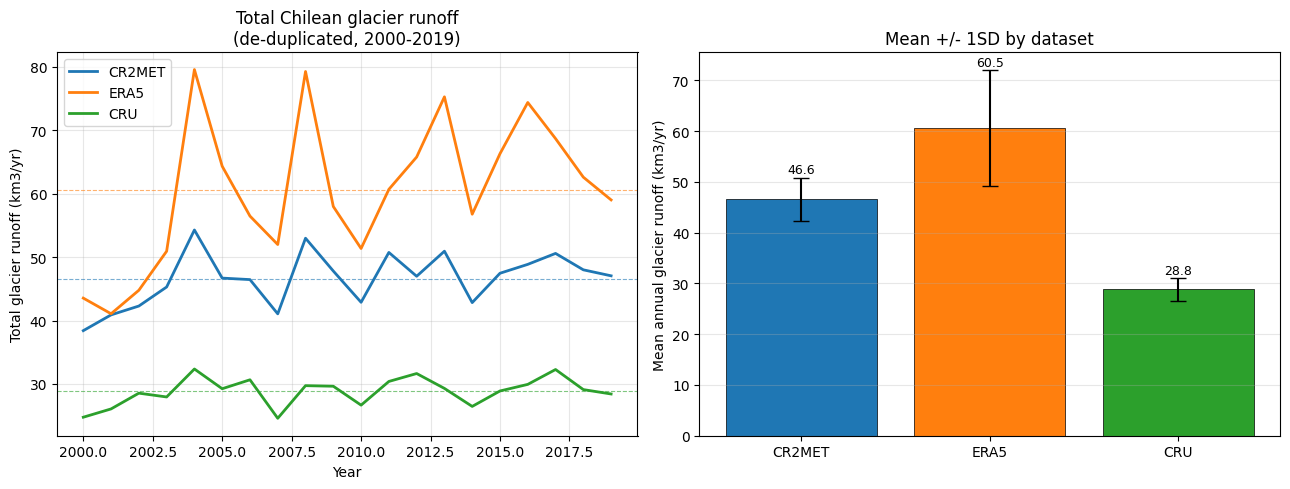

In [17]:
# ── Cell 11: Figure 1 — National melt totals ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for ds_name in DATASETS:
    km3 = NATIONAL_TOTALS[ds_name] / 1e9
    ax.plot(YEARS, km3, color=DS_COLORS[ds_name], lw=2, label=ds_name)
    ax.axhline(km3.mean(), color=DS_COLORS[ds_name], lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('Year')
ax.set_ylabel('Total glacier runoff (km3/yr)')
ax.set_title('Total Chilean glacier runoff\n(de-duplicated, 2000-2019)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
means = {ds: (NATIONAL_TOTALS[ds]/1e9).mean() for ds in DATASETS}
stds  = {ds: (NATIONAL_TOTALS[ds]/1e9).std()  for ds in DATASETS}
bars  = ax.bar(list(means.keys()), list(means.values()),
               color=[DS_COLORS[d] for d in means],
               yerr=list(stds.values()), capsize=6, edgecolor='k', lw=0.5)
for bar, (ds, val) in zip(bars, means.items()):
    ax.text(bar.get_x() + bar.get_width()/2, val + stds[ds] + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Mean annual glacier runoff (km3/yr)')
ax.set_title('Mean +/- 1SD by dataset')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig1_national_melt_totals.png', dpi=150)
plt.show()

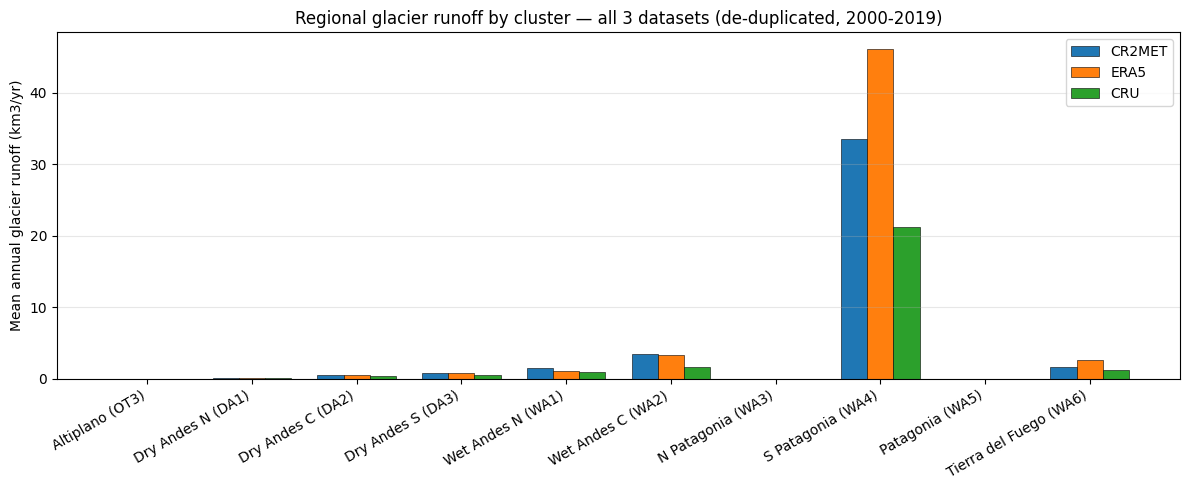

In [18]:
# ── Cell 12: Figure 2 — Regional melt by cluster ──────────────────────────

cluster_melt = {}
for ds_name in DATASETS:
    cluster_totals = {cl: 0.0 for cl in CLUSTERS}
    for gauge_id, info in GAUGE_INFO_DEDUP.items():
        res = RESULTS[ds_name].get(gauge_id)
        if res is None:
            continue
        total = res['monthly']['glacier_runoff_m3'].sum() / 1e9 / 20
        pc    = info['primary_cluster']
        if pc in cluster_totals:
            cluster_totals[pc] += total
    cluster_melt[ds_name] = cluster_totals

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(CLUSTERS))
width = 0.25
for i, ds_name in enumerate(DATASETS):
    vals = [cluster_melt[ds_name].get(cl, 0) for cl in CLUSTERS]
    ax.bar(x + i*width, vals, width, label=ds_name,
           color=DS_COLORS[ds_name], edgecolor='k', lw=0.4)
ax.set_xticks(x + width)
ax.set_xticklabels([REGION_LABELS[c] for c in CLUSTERS], rotation=30, ha='right')
ax.set_ylabel('Mean annual glacier runoff (km3/yr)')
ax.set_title('Regional glacier runoff by cluster — all 3 datasets (de-duplicated, 2000-2019)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig2_regional_melt_by_cluster.png', dpi=150)
plt.show()

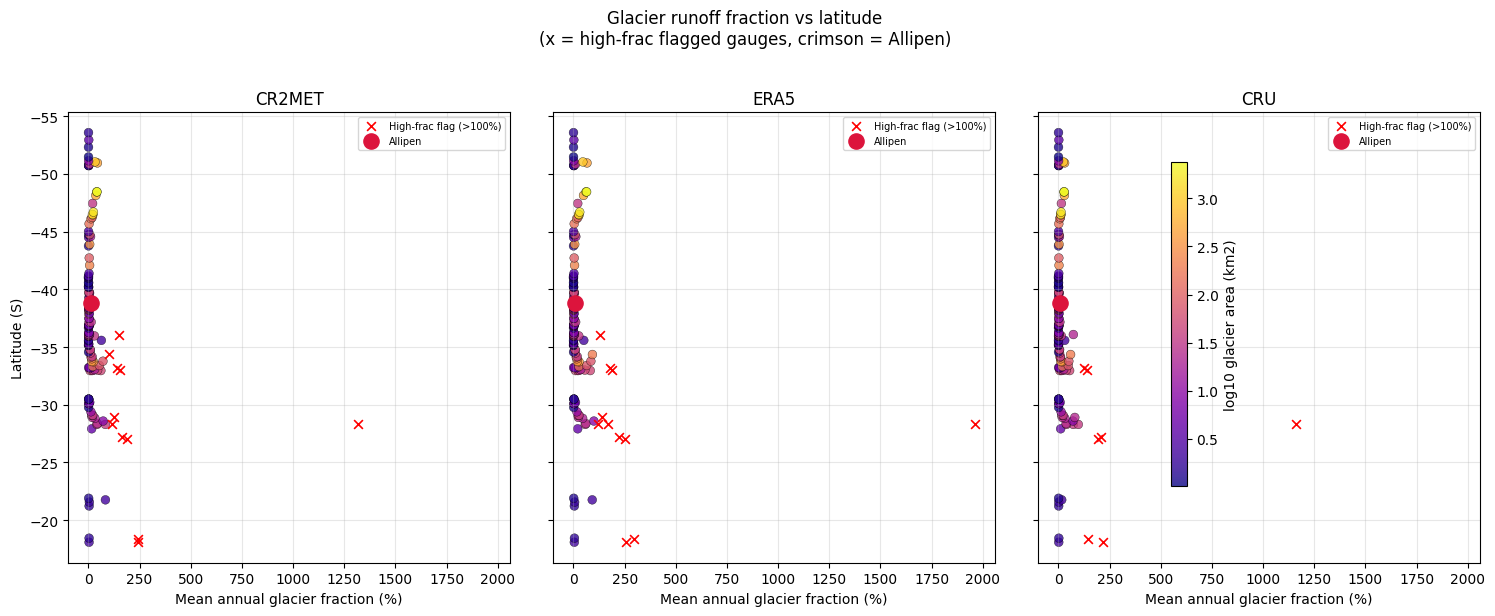

In [19]:
# ── Cell 13: Figure 3 — Latitudinal gradient ──────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True, sharex=True)

for ax, ds_name in zip(axes, DATASETS):
    df     = ANN_SUMMARIES[ds_name].dropna(subset=['mean_ann_frac'])
    df_ok  = df[~df['high_frac_flag']]
    df_hf  = df[df['high_frac_flag']]

    sc = ax.scatter(df_ok['mean_ann_frac'] * 100, df_ok['lat'],
                    c=np.log10(df_ok['glacier_area_km2'] + 1),
                    cmap='plasma', s=40, edgecolors='k', lw=0.3, alpha=0.8)
    if len(df_hf):
        ax.scatter(df_hf['mean_ann_frac'] * 100, df_hf['lat'],
                   marker='x', color='red', s=40, lw=1.2,
                   label='High-frac flag (>100%)', zorder=6)

    allipen = df[df['gauge_id'] == '9402001']
    if len(allipen):
        ax.scatter(allipen['mean_ann_frac']*100, allipen['lat'],
                   s=120, color='crimson', zorder=7, label='Allipen')

    ax.set_title(ds_name)
    ax.set_xlabel('Mean annual glacier fraction (%)')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

axes[0].set_ylabel('Latitude (S)')
fig.colorbar(sc, ax=axes, label='log10 glacier area (km2)', shrink=0.7)
fig.suptitle('Glacier runoff fraction vs latitude\n'
             '(x = high-frac flagged gauges, crimson = Allipen)', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig3_latitudinal_gradient.png', dpi=150, bbox_inches='tight')
plt.show()

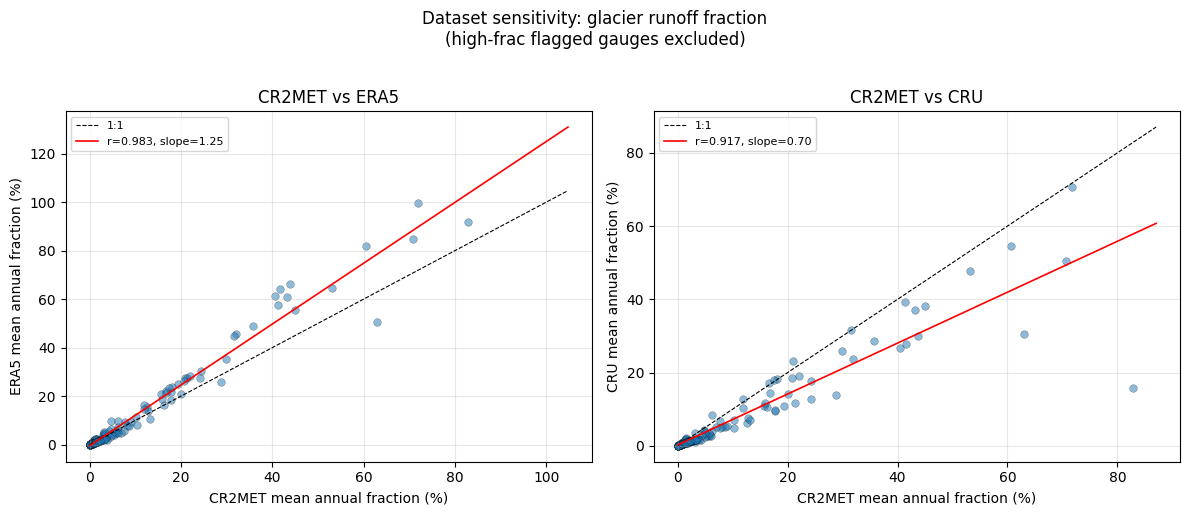

In [20]:
# ── Cell 14: Figure 4 — Dataset comparison scatter ────────────────────────

combined_clean = combined[~combined['high_frac_flag']].copy()
frac_pivot = combined_clean.pivot_table(
    index='gauge_id', columns='dataset', values='mean_ann_frac').dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, alt_ds in zip(axes, ['ERA5','CRU']):
    x = frac_pivot['CR2MET'] * 100
    y = frac_pivot[alt_ds]   * 100
    ax.scatter(x, y, alpha=0.5, s=30, edgecolors='k', lw=0.3)
    lim = max(x.max(), y.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='1:1')
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xfit = np.linspace(0, lim, 100)
    ax.plot(xfit, slope*xfit + intercept, 'r-', lw=1.2,
            label=f'r={r:.3f}, slope={slope:.2f}')
    ax.set_xlabel('CR2MET mean annual fraction (%)')
    ax.set_ylabel(f'{alt_ds} mean annual fraction (%)')
    ax.set_title(f'CR2MET vs {alt_ds}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Dataset sensitivity: glacier runoff fraction\n'
             '(high-frac flagged gauges excluded)', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig4_dataset_comparison_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

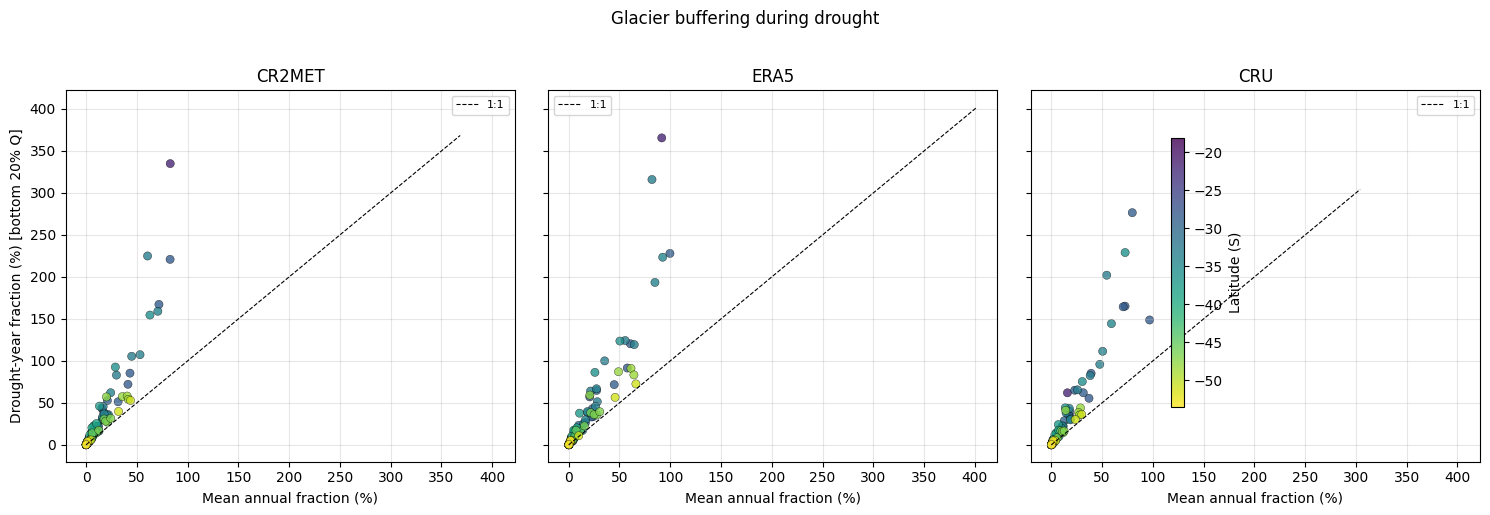

In [21]:
# ── Cell 15: Figure 5 — Drought amplification ─────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, ds_name in zip(axes, DATASETS):
    df = ANN_SUMMARIES[ds_name].dropna(
        subset=['drought_ann_frac','mean_ann_frac']).copy()
    df = df[~df['high_frac_flag']]
    sc = ax.scatter(df['mean_ann_frac']*100, df['drought_ann_frac']*100,
                    c=df['lat'], cmap='viridis_r',
                    s=35, edgecolors='k', lw=0.3, alpha=0.8)
    lim = max(df['drought_ann_frac'].max(), df['mean_ann_frac'].max()) * 110
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='1:1')
    ax.set_title(ds_name)
    ax.set_xlabel('Mean annual fraction (%)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Drought-year fraction (%) [bottom 20% Q]')
fig.colorbar(sc, ax=axes, label='Latitude (S)', shrink=0.7)
fig.suptitle('Glacier buffering during drought', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig5_drought_amplification.png', dpi=150, bbox_inches='tight')
plt.show()

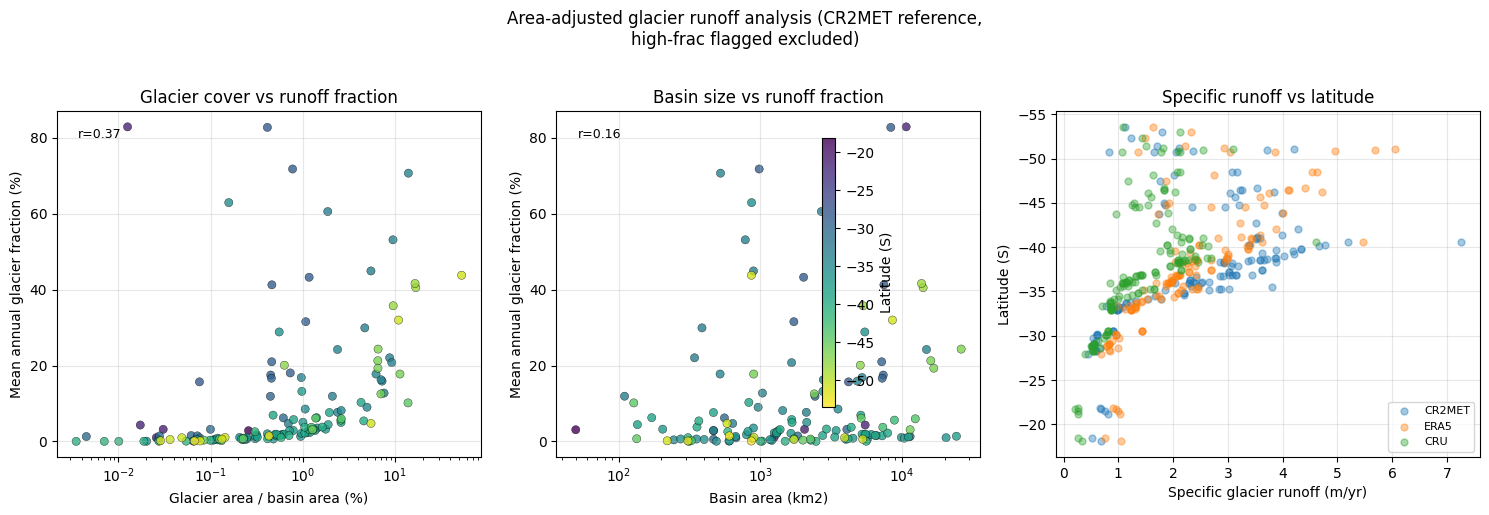

In [22]:
# ── Cell 16: Figure 6 — Area-adjusted analysis ────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df_cr2 = ANN_SUMMARIES['CR2MET'].dropna(subset=['mean_ann_frac']).copy()
df_cr2 = df_cr2[~df_cr2['high_frac_flag']]
df_cr2['specific_runoff'] = (
    df_cr2['mean_ann_glac_km3'] * 1e9 / df_cr2['glacier_area_km2'] / 1e6)

ax = axes[0]
sc = ax.scatter(df_cr2['glacier_pct_basin'], df_cr2['mean_ann_frac']*100,
                c=df_cr2['lat'], cmap='viridis_r',
                s=35, edgecolors='k', lw=0.3, alpha=0.8)
ax.set_xscale('log')
ax.set_xlabel('Glacier area / basin area (%)')
ax.set_ylabel('Mean annual glacier fraction (%)')
ax.set_title('Glacier cover vs runoff fraction')
r, _ = stats.pearsonr(np.log10(df_cr2['glacier_pct_basin'].clip(lower=0.001)),
                       df_cr2['mean_ann_frac'])
ax.text(0.05, 0.95, f'r={r:.2f}', transform=ax.transAxes, va='top', fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(df_cr2['basin_area_km2'], df_cr2['mean_ann_frac']*100,
           c=df_cr2['lat'], cmap='viridis_r',
           s=35, edgecolors='k', lw=0.3, alpha=0.8)
ax.set_xscale('log')
ax.set_xlabel('Basin area (km2)')
ax.set_ylabel('Mean annual glacier fraction (%)')
ax.set_title('Basin size vs runoff fraction')
r2, _ = stats.pearsonr(np.log10(df_cr2['basin_area_km2']), df_cr2['mean_ann_frac'])
ax.text(0.05, 0.95, f'r={r2:.2f}', transform=ax.transAxes, va='top', fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[2]
for ds_name in DATASETS:
    df_ds = ANN_SUMMARIES[ds_name].copy()
    df_ds = df_ds[~df_ds['high_frac_flag']]
    df_ds['specific_runoff'] = (
        df_ds['mean_ann_glac_km3'] * 1e9 / df_ds['glacier_area_km2'] / 1e6)
    ax.scatter(df_ds['specific_runoff'], df_ds['lat'],
               alpha=0.4, s=25, color=DS_COLORS[ds_name], label=ds_name)
ax.set_xlabel('Specific glacier runoff (m/yr)')
ax.set_ylabel('Latitude (S)')
ax.set_title('Specific runoff vs latitude')
ax.invert_yaxis()
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.colorbar(sc, ax=axes[:2], label='Latitude (S)', shrink=0.7)
fig.suptitle('Area-adjusted glacier runoff analysis (CR2MET reference,\nhigh-frac flagged excluded)', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig6_area_adjusted_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

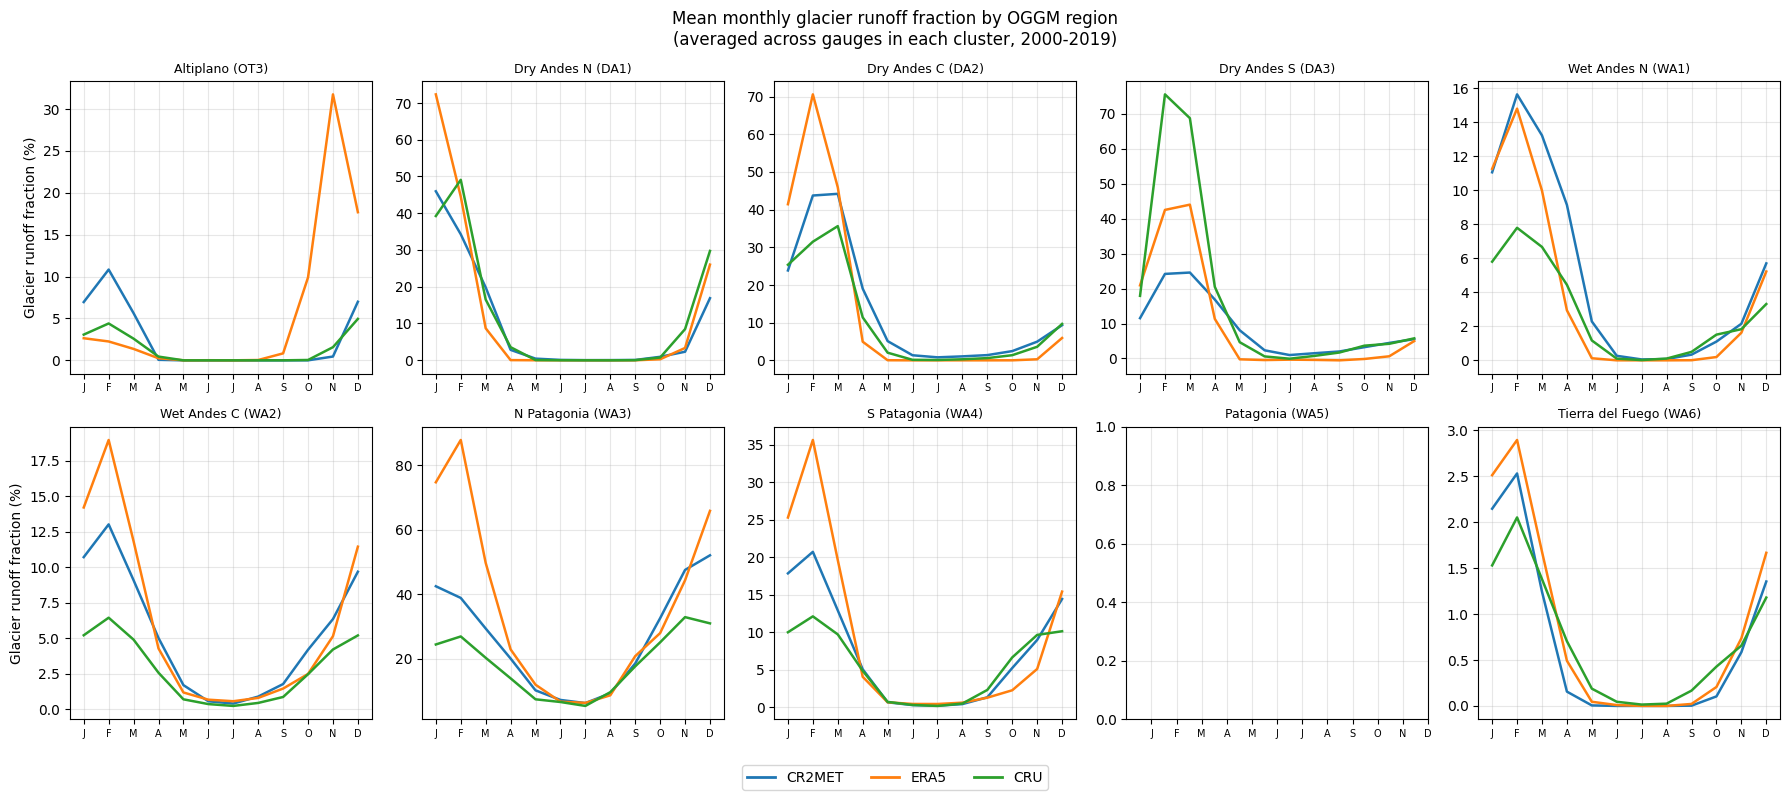

In [23]:
# ── Cell 17: Figure 7 — Monthly seasonality by region ─────────────────────

fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=False)
axes_flat = axes.flatten()
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

for ax, cl in zip(axes_flat, CLUSTERS):
    for ds_name in DATASETS:
        df = ANN_SUMMARIES[ds_name]
        gauges_in_cl = df[
            (df['primary_cluster'] == cl) & (~df['high_frac_flag'])
        ]['gauge_id'].tolist()
        if not gauges_in_cl:
            continue
        mon_fracs = []
        for gid in gauges_in_cl:
            res = RESULTS[ds_name].get(gid)
            if res is None:
                continue
            m = res['monthly']
            mf = m.groupby('month').apply(
                lambda g: g['glacier_runoff_m3'].sum() / g['q_m3_mon'].sum()
                if g['q_m3_mon'].sum() > 0 else np.nan)
            mon_fracs.append(mf)
        if mon_fracs:
            mean_mf = pd.concat(mon_fracs, axis=1).mean(axis=1)
            ax.plot(mean_mf.index, mean_mf.values*100,
                    color=DS_COLORS[ds_name], lw=1.8, label=ds_name)

    ax.set_title(REGION_LABELS[cl], fontsize=9)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=7)
    ax.grid(True, alpha=0.3)

axes[0,0].set_ylabel('Glacier runoff fraction (%)')
axes[1,0].set_ylabel('Glacier runoff fraction (%)')
handles = [plt.Line2D([0],[0], color=DS_COLORS[d], lw=2, label=d) for d in DATASETS]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10)
fig.suptitle('Mean monthly glacier runoff fraction by OGGM region\n'
             '(averaged across gauges in each cluster, 2000-2019)')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f'{OUT_DIR}/fig7_monthly_seasonality_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ── Cell 18: Summary statistics ───────────────────────────────────────────

print('=' * 70)
print('SUMMARY STATISTICS — All-Chile Glacier Runoff Analysis')
print('=' * 70)

print(f'\nSpatial coverage:')
print(f'  Total RGI glaciers:                   {len(rgi_gdf):>6}')
print(f'  Glaciers matched to a gauge:          {joined_valid["RGIId"].nunique():>6}')
print(f'  Gauges with glaciers + Q data:        {len(GAUGE_INFO):>6}')
print(f'  Gauges passing Q completeness filter: {len(GAUGE_INFO_FRAC):>6}')
print(f'  Gauges with high-frac flag (>100%):   '
      f'{len(hf_df):>6}  (flagged, not excluded)')

print(f'\nNational glacier runoff (de-duplicated, 2000-2019 mean):')
for ds_name in DATASETS:
    mean_km3 = NATIONAL_TOTALS[ds_name].mean() / 1e9
    std_km3  = NATIONAL_TOTALS[ds_name].std()  / 1e9
    print(f'  {ds_name:8s}: {mean_km3:.2f} +/- {std_km3:.2f} km3/yr')

print(f'\nMean annual glacier fraction (non-flagged gauges only):')
for ds_name in DATASETS:
    df = ANN_SUMMARIES[ds_name]
    df_ok = df[~df['high_frac_flag']]
    print(f'  {ds_name:8s}: mean={df_ok["mean_ann_frac"].mean()*100:.2f}%  '
          f'median={df_ok["mean_ann_frac"].median()*100:.2f}%  '
          f'max={df_ok["mean_ann_frac"].max()*100:.1f}%')

print(f'\nAllipen (9402001) — CR2MET:')
cr2_idx = ANN_SUMMARIES['CR2MET'].set_index('gauge_id')
if '9402001' in cr2_idx.index:
    row = cr2_idx.loc['9402001']
    print(f'  n_glaciers:        {row["n_glaciers"]}')
    print(f'  glacier_area:      {row["glacier_area_km2"]:.1f} km2')
    print(f'  mean_ann_frac:     {row["mean_ann_frac"]*100:.1f}%')
    print(f'  drought_frac:      {row["drought_ann_frac"]*100:.1f}%')
    print(f'  n_complete_q_yrs:  {row["n_complete_q_years"]}')

print(f'\nOutputs saved to: {OUT_DIR}')

SUMMARY STATISTICS — All-Chile Glacier Runoff Analysis

Spatial coverage:
  Total RGI glaciers:                    13246
  Glaciers matched to a gauge:            6883
  Gauges with glaciers + Q data:           266
  Gauges passing Q completeness filter:    151
  Gauges with high-frac flag (>100%):       11  (flagged, not excluded)

National glacier runoff (de-duplicated, 2000-2019 mean):
  CR2MET  : 46.62 +/- 4.23 km3/yr
  ERA5    : 60.55 +/- 11.41 km3/yr
  CRU     : 28.82 +/- 2.23 km3/yr

Mean annual glacier fraction (non-flagged gauges only):
  CR2MET  : mean=10.96%  median=3.11%  max=82.9%
  ERA5    : mean=13.22%  median=2.53%  max=99.7%
  CRU     : mean=9.88%  median=1.71%  max=96.8%

Allipen (9402001) — CR2MET:
  n_glaciers:        92
  glacier_area:      35.6 km2
  mean_ann_frac:     10.3%
  drought_frac:      25.4%
  n_complete_q_yrs:  14

Outputs saved to: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2
